<a href="https://colab.research.google.com/github/MohsinYaseen309/Mask-Detection-System/blob/main/mask_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense, Flatten,
Dropout, BatchNormalization,
GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
print("TensorFlow version:", tf.__version__)

2026-01-09 17:17:10.437027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767979030.633637     107 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767979030.689219     107 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TensorFlow version: 2.18.0


In [ ]:
BASE_DIR = "../input/mask-detection-dataset/data"
WITH_MASK_DIR = os.path.join(BASE_DIR, "with-mask")
WITHOUT_MASK_DIR = os.path.join(BASE_DIR, "without-mask")


assert os.path.exists(BASE_DIR), "Dataset path not found!"


print("With mask images:", len(os.listdir(WITH_MASK_DIR)))
print("Without mask images:", len(os.listdir(WITHOUT_MASK_DIR)))

With mask images: 150
Without mask images: 150


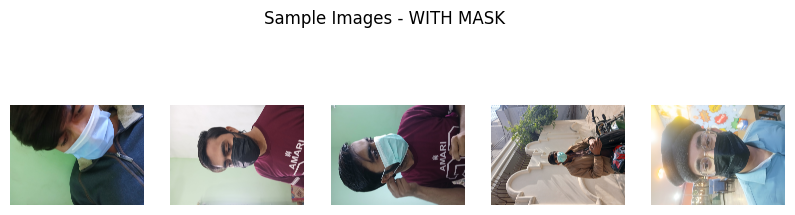

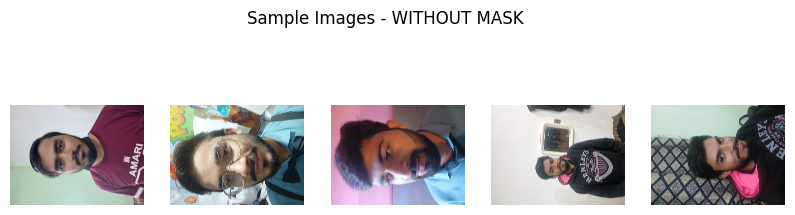

In [ ]:
def show_samples(folder, title):
    images = glob(folder + "/*")[:5]
    plt.figure(figsize=(10, 3))
    for i, img_path in enumerate(images):
        img = plt.imread(img_path)
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(title)
    plt.show()


show_samples(WITH_MASK_DIR, "Sample Images - WITH MASK")
show_samples(WITHOUT_MASK_DIR, "Sample Images - WITHOUT MASK")

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)


val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


train_generator = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)


val_generator = val_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


print("Class Indices:", train_generator.class_indices)

Found 240 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Class Indices: {'with-mask': 0, 'without-mask': 1}


In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),


    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),


    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),


    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


cnn_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


cnn_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1767979054.960475     107 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767979054.961067     107 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("cnn_face_mask_model.h5", save_best_only=True)
]

history_cnn = cnn_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1767979071.284129     176 service.cc:148] XLA service 0x7edc800139d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767979071.285026     176 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767979071.285047     176 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767979071.789362     176 cuda_dnn.cc:529] Loaded cuDNN version 90300


2/8 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4297 - loss: 1.6022 

I0000 00:00:1767979077.091899     176 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5242 - loss: 1.4440

8/8 ━━━━━━━━━━━━━━━━━━━━ 52s 6s/step - accuracy: 0.5326 - loss: 1.4172 - val_accuracy: 0.5333 - val_loss: 0.6776
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.8243 - loss: 0.6247 - val_accuracy: 0.5167 - val_loss: 0.7062
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8405 - loss: 0.4506 - val_accuracy: 0.5000 - val_loss: 0.8666
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8536 - loss: 0.3640 - val_accuracy: 0.5000 - val_loss: 1.1444
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.8907 - loss: 0.2402 - val_accuracy: 0.5000 - val_loss: 1.5514
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.8979 - loss: 0.2190 - val_accuracy: 0.5000 - val_loss: 2.1082


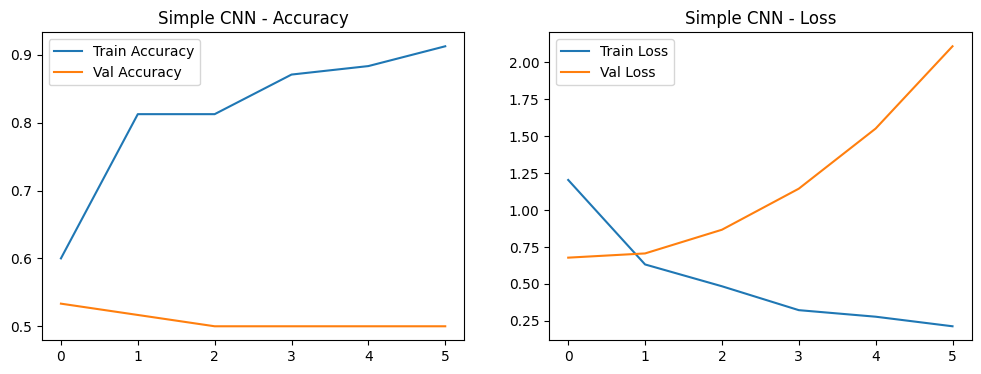

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))


    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.legend()
    plt.title(title + " - Accuracy")


    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title(title + " - Loss")


    plt.show()


plot_history(history_cnn, "Simple CNN")

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


# Freeze base model
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)


transfer_model = Model(inputs=base_model.input, outputs=output)


transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("mobilenetv2_face_mask_model.h5", save_best_only=True)
]


history_tl = transfer_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=callbacks_tl
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5203 - loss: 0.8834

8/8 ━━━━━━━━━━━━━━━━━━━━ 44s 5s/step - accuracy: 0.5273 - loss: 0.8743 - val_accuracy: 0.3667 - val_loss: 0.8814
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6516 - loss: 0.7032

8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.6528 - loss: 0.7008 - val_accuracy: 0.4667 - val_loss: 0.7564
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6081 - loss: 0.6789

8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6104 - loss: 0.6756 - val_accuracy: 0.6167 - val_loss: 0.6822
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7231 - loss: 0.5499

8/8 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.7228 - loss: 0.5488 - val_accuracy: 0.7167 - val_loss: 0.6239
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7446 - loss: 0.5384

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8373 - loss: 0.3560 - val_accuracy: 0.8500 - val_loss: 0.4501
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8747 - loss: 0.3191

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8761 - loss: 0.3164 - val_accuracy: 0.8667 - val_loss: 0.4326
Epoch 13/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8974 - loss: 0.2873

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8976 - loss: 0.2865 - val_accuracy: 0.8333 - val_loss: 0.4208
Epoch 14/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9013 - loss: 0.2425

8/8 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.8998 - loss: 0.2458 - val_accuracy: 0.8667 - val_loss: 0.4032
Epoch 15/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8777 - loss: 0.3139

8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.8802 - loss: 0.3093 - val_accuracy: 0.8833 - val_loss: 0.3945


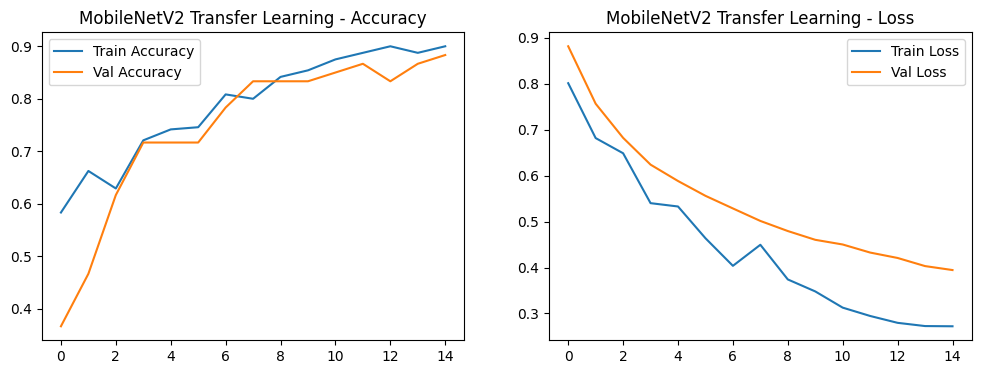

In [ ]:
plot_history(history_tl, "MobileNetV2 Transfer Learning")

In [ ]:
from tensorflow.keras.preprocessing import image


# Load best trained model (MobileNetV2 performs better)
inference_model = tf.keras.models.load_model("mobilenetv2_face_mask_model.h5")


CLASS_NAMES = {0: "WITH MASK", 1: "WITHOUT MASK"}




def predict_image(img_path, model):
    """
    Loads an image, preprocesses it, and predicts mask status
    """
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    prediction = model.predict(img_array)[0][0]
    label = 1 if prediction >= 0.5 else 0


    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {CLASS_NAMES[label]}")
    plt.show()


    print("Raw Prediction Score:", prediction)
    print("Predicted Class:", CLASS_NAMES[label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


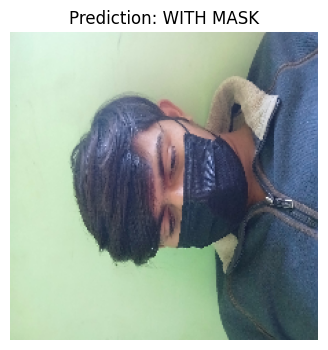

Raw Prediction Score: 0.40226048
Predicted Class: WITH MASK


In [ ]:
sample_test_image = glob(WITH_MASK_DIR + "/*")[0]
predict_image("/kaggle/input/mask-detection-dataset/data/with-mask/20260104_122949.jpg", inference_model)

In [ ]:
%%writefile app.py
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("mobilenetv2_face_mask_model.h5")
# Wrapper function for Gradio
def gradio_predict(img):
    img = img.resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    prediction = inference_model.predict(img_array)[0][0]
    label = "WITHOUT MASK ❌" if prediction >= 0.5 else "WITH MASK 😷"
    confidence = prediction if prediction >= 0.5 else 1 - prediction


    return label, float(confidence)


interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload Face Image"),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Number(label="Confidence Score")
    ],
    title="Face Mask Detection System",
    description="Upload an image to check whether the person is wearing a face mask."
)


interface.launch(share=True)

Writing app.py


In [ ]:
%%writefile requirements.txt
tensorflow
numpy
matplotlib
gradio
Pillow

Writing requirements.txt


In [ ]:
import gradio as gr

def gradio_predict(img):
    img = img.resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)


    prediction = inference_model.predict(img_array)[0][0]
    label = "WITHOUT MASK ❌" if prediction >= 0.5 else "WITH MASK 😷"
    confidence = prediction if prediction >= 0.5 else 1 - prediction


    return label, float(confidence)


interface = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Upload Face Image"),
    outputs=[
        gr.Label(label="Prediction"),
        gr.Number(label="Confidence Score")
    ],
    title="Face Mask Detection System",
    description="Upload an image to check whether the person is wearing a face mask."
)


interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://274605982512cea16a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Created dataset file at: .gradio/flagged/dataset1.csv
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
